# <center>Factor Regressions</center>

$$ R_t - R_{f,t} = \alpha + \beta_1 (Mkt - R_f)_t + \beta_2 SMB_t + \beta_3 HML_t + \beta_4 RMW_t + \beta_5 CMA_t + \beta_6 MOM_t + \epsilon_t $$

In [45]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import getFamaFrenchFactors as gff

In [46]:
rets=yf.download(['VTI','AVUV'],interval='1mo',start='1900-01-01',auto_adjust=True)['Close']
rets=rets.to_period('M').pct_change().dropna()

[*********************100%***********************]  2 of 2 completed


<Axes: xlabel='Date'>

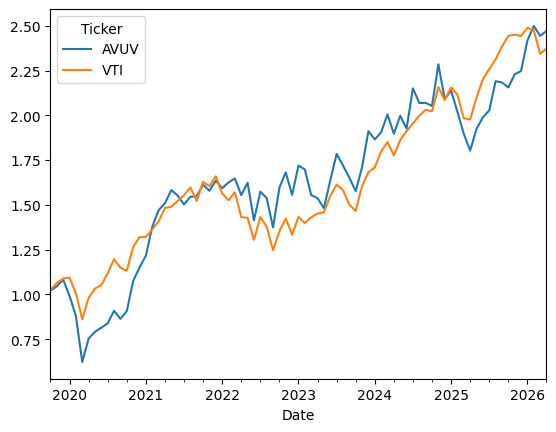

In [47]:
(1+rets).cumprod().plot()

In [48]:
fft_5_factor_model = gff.famaFrench5Factor().set_index('date_ff_factors').to_period('M')
ff_momentum_factor = gff.momentumFactor().set_index('date_ff_factors').to_period('M')

fft_6_factor_model = fft_5_factor_model.join(ff_momentum_factor)
fft_6_factor_model = fft_6_factor_model[[*fft_6_factor_model.columns.drop('RF'),'RF']]

In [49]:
fft_6_factor_model

,Mkt-RF,SMB,HML,RMW,CMA,MOM,RF
date_ff_factors,,,,,,,
1963-07,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0101,0.0027
1963-08,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0100,0.0025
1963-09,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0012,0.0027
1963-10,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0313,0.0029
1963-11,-0.0086,-0.0085,0.0173,-0.0043,0.0227,-0.0078,0.0027
...,...,...,...,...,...,...,...
2025-10,0.0196,-0.0131,-0.0310,-0.0524,-0.0403,0.0027,0.0037
2025-11,-0.0013,0.0147,0.0376,0.0144,0.0068,-0.0180,0.0030
2025-12,-0.0036,-0.0022,0.0242,0.0040,0.0037,-0.0241,0.0034


<Axes: xlabel='date_ff_factors'>

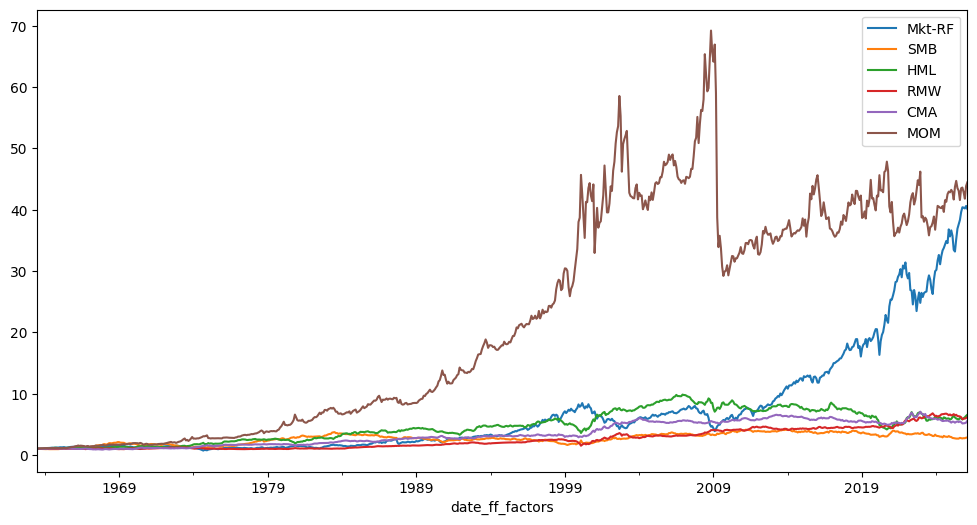

In [44]:
(1+fft_6_factor_model).cumprod().plot(figsize=(12,6))